In [3]:
import numpy as np
from pymatgen.core import Structure, Lattice
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import time

In [4]:
import numba as nb

In [5]:
def get_optical_axis_direction(structure: Structure):
    """
    Определяет направление оптической оси в декартовых координатах.
    
    Для одноосных кристаллов (тригональные, гексагональные, тетрагональные)
    оптическая ось совпадает с осью c (третий вектор решётки).
    
    Для кубических — возвращает None (изотропный).
    Для двуосных — нужно задать вручную.
    
    Возвращает:
        numpy.ndarray: единичный вектор оптической оси (в декартовых координатах)
        str: тип ('uniaxial', 'cubic', 'biaxial')
    """
    # Приводим к стандартной ячейке
    sga = SpacegroupAnalyzer(structure)
    crystal_system = sga.get_crystal_system()
    conventional = sga.get_conventional_standard_structure()

    
    print(f"Сингония: {crystal_system}")
    
    if crystal_system in ['trigonal', 'hexagonal', 'tetragonal']:
        # Одноосные кристаллы: оптическая ось = ось c
        c_vector = conventional.lattice.matrix[2]
        optical_axis = c_vector / np.linalg.norm(c_vector)
        return optical_axis, 'uniaxial'
    
    elif crystal_system == 'cubic':
        # Изотропный — оптической оси нет
        return None, 'cubic'
    
    else:
        # Двуосные или другие: нужно задавать вручную
        return None, 'biaxial'


In [6]:
def rotate_structure_optical_axis_to_x(
    structure: Structure,
    manual_axis: np.ndarray = None
):
    sga = SpacegroupAnalyzer(structure)
    crystal_system = sga.get_crystal_system()
    conventional = sga.get_conventional_standard_structure()
    V_cell = conventional.volume * 1e-24
    optical_axis, crystal_type = get_optical_axis_direction(structure)

    

    if crystal_type == 'cubic':
        target = np.array([1.0, 0.0, 0.0])
        a_vector = conventional.lattice.matrix[0]
        a_unit = a_vector/np.linalg.norm(a_vector)

        cross = np.cross(a_unit, target)
        norm = np.linalg.norm(cross)

        if norm <1e-12:
            if np.dot(a_unit, target) > 0:
                rot_matrix = np.eye(3)
            else:
                rot_matrix = Rotation.from_rotvec(np.pi * np.array([0,1,0])).as_matrix()
        else:
            axis = cross / norm
            angle = np.arccos(np.clip(np.dot(a_unit, target), -1, 1))
            rot_matrix = Rotation.from_rotvec(angle * axis).as_matrix()

        new_lattice = rot_matrix @ conventional.lattice.matrix.T
        new_lattice = new_lattice.T
        new_coords = []
        for site in conventional:
            new_coords.append(rot_matrix @ site.coords)
        rotated = Structure(
            lattice = Lattice(new_lattice),
            species = [site.species for site in conventional],
            coords = new_coords,
            coords_are_cartesian = True
        )
        return rotated, target, V_cell
        

        

    


In [7]:
def get_lattice_vectors(structure):
    """
    Возвращает векторы решётки в сантиметрах (СГС).
    Матрица в pymatgen имеет форму (3, 3), где строки — это векторы a, b, c.
    """
    lattice = structure.lattice.matrix * 1e-8  # Из Ангстремов в см
    return lattice[0], lattice[1], lattice[2]

In [8]:
def replicate_along_z_pymatgen(structure, N):
    supercell = structure.copy()
    supercell.make_supercell([1,1,N])

    coords = supercell.cart_coords *1e-8
    types = np.array([site.species_string for site in supercell])
    x_all = coords[:,0]
    y_all = coords[:,1]
    z_all = coords[:,2]
    types_all = types
    return supercell, x_all, y_all, z_all, types_all


In [9]:
# omega = 3e15
omega = 9e17
c = 2.998e10 
e = 4.803e-10



params0 = {
    'C'  : {'m': 1.6e-26,  'k': 4.7e6},
    'O'  : {'m': 4.3e-26,  'k': 1.8e7},
    'Mg' : {'m': 0,  'k': 3.1e5}, # 'm': 2.3e-26
    'S'  : {'m': 0,  'k': 2.0e5}, # 'm': 8.3e-26
    'Ca' : {'m': 4.7e-26,  'k': 4.1e6},
    'Zn' : {'m': 1.8e-25,  'k': 3.6e7},
    'Cd' : {'m': 4.0e-25,  'k': 7.4e7},
}      

N_perp = 100 # количество слоёв вверх и столько же вниз

N = 20 # кол-во ячеек вдоль направления распространения

In [10]:
def build_shifts(a_vec, b_vec, N_perp):
    nx_vals = np.arange(-N_perp, N_perp + 1)
    ny_vals = np.arange(-N_perp, N_perp + 1)
    n_shifts = len(nx_vals) * len(ny_vals)
    shifts = np.zeros((n_shifts, 3), dtype = np.float64)
    zero_idx = -1
    idx = 0

    for nx in nx_vals:
        for ny in ny_vals:
            shifts[idx, 0] = 2.0 * (nx * a_vec[0] + ny * b_vec[0])
            shifts[idx, 1] = 2.0 * (nx * a_vec[1] + ny * b_vec[1])
            shifts[idx, 2] = 2.0 * (nx * a_vec[2] + ny * b_vec[2])
            if nx == 0 and ny == 0:
                zero_idx = idx
            idx += 1
    return shifts, zero_idx



In [25]:
@nb.njit(parallel = True, fastmath = True)
def build_A_matrix(coords, shifts, zero_idx, omega, masses, springs, r_cut):
    L = coords.shape[0]
    A = np.zeros((3 * L, 3 * L), dtype = np.complex64)
    factor = omega / c
    n_shifts = shifts.shape[0]
    a = 0
    for i in range(L):
        diag_val = (springs[i] - omega ** 2 * masses[i]) / e**2
        a+=diag_val
        ii = 3 * i
        A[ii, ii] += diag_val
        A[ii + 1, ii + 1] += diag_val
        A[ii + 2, ii + 2] += diag_val
    b = 0   
    for i in nb.prange(L):
        # print(f'A {i}')
        xi0 = coords[i,0]
        xi1 = coords[i,1]
        xi2 = coords[i,2]
        for j in range(i, L):
            xj0 = coords[j,0]
            xj1 = coords[j, 1]
            xj2 = coords[j, 2]
    
            s_xx = 0.0 + 0.0j
            s_yy = 0.0 + 0.0j
            s_zz = 0.0 + 0.0j
            s_xy = 0.0 + 0.0j
            s_xz = 0.0 + 0.0j
            s_yz = 0.0 + 0.0j
    
            for k in range(n_shifts):
                if i == j and k == zero_idx:
                    continue
    
                lx = xi0 - (xj0 + shifts[k,0])
                ly = xi1 - (xj1 + shifts[k,1])
                lz = xi2 - (xj2 + shifts[k,2])
    
                r2 = lx * lx + ly * ly + lz * lz
                r = np.sqrt(r2)
                if r > r_cut:
                    continue
                r3 = r * r * r
                r4 = r * r3
                r5 = r * r * r3
                phase = np.exp(-1j * factor * r)
    
                t1a = 3.0 / r5
                t1b = 1.0 / r3
                t2a = 3.0 / (c * r4)
                t2b = 1.0 / (c * r2)
                t3a = 1.0 / (c * c * r3)
                t3b = 1.0 / (c * c * r)
                coeff_1 = -(t1a - 1j * omega * t2a - omega **2 * t3a)
                coeff_2 = (t1b - 1j * omega * t2b - omega **2 * t3b)
                g_xx = (coeff_1 * lx * lx + coeff_2) * phase
                g_yy = (coeff_1 * ly * ly + coeff_2) * phase
                g_zz = (coeff_1 * lz * lz + coeff_2) * phase
                g_xy = coeff_1 * lx * ly * phase
                g_xz = coeff_1 * lx * lz * phase
                g_yz = coeff_1 * ly * lz * phase
                s_xx += g_xx
                s_yy += g_yy
                s_zz += g_zz
                s_xy += g_xy
                s_xz += g_xz
                s_yz += g_yz
            ii = 3 * i
            jj = 3 * j
            A[ii, jj] += s_xx
            A[ii, jj + 1] += s_xy
            A[ii, jj + 2] += s_xz
            A[ii + 1, jj] += s_xy
            A[ii + 1, jj + 1] += s_yy
            A[ii + 1, jj + 2] += s_yz
            A[ii + 2, jj] += s_xz
            A[ii + 2, jj + 1] += s_yz
            A[ii + 2, jj + 2] += s_zz
            if i != j:
                A[jj, ii] += s_xx
                A[jj, ii + 1] += s_xy
                A[jj, ii + 2] += s_xz
                A[jj + 1, ii] += s_xy
                A[jj + 1, ii + 1] += s_yy
                A[jj + 1, ii + 2] += s_yz
                A[jj + 2, ii] += s_xz
                A[jj + 2, ii + 1] += s_yz
                A[jj + 2, ii + 2] += s_zz
    return A   

In [12]:
def q_mod(coords, shifts, zero_idx, omega, params, types_all, r_cut, theta = 0.0, E0 = 0.03):
        L = len(types_all)
        print("Это q_mod")
        print('N = ', L // 8)
        print('N_perp = ', np.sqrt(len(shifts)))
        print('params[Mg]:', params['Mg'])
        print('omega = ', omega)

        
        ### реплицирование, потом передавать уже нормальные ячейки
        
        masses = np.array([params[t]['m'] for t in types_all])
        springs = np.array([params[t]['k'] for t in types_all])
        A = build_A_matrix(coords, shifts, zero_idx, omega, masses, springs, r_cut)
        b = np.zeros(3 * L, dtype = 'complex')
        theta_rad = theta / 180 * np.pi
        for i in range(L):
              z = z_all[i]
              phase = np.exp(-1j * omega * z / c)
              b[3 * i] = E0 * np.cos(theta_rad) * phase
              b[3 * i + 1] = E0 * np.sin(theta_rad) * phase
              b[3 * i + 2] = 0
        q = np.linalg.solve(A, b)
        return q

In [31]:
params0 = {
    'C'  : {'m': 1.6e-26,  'k': 4.7e6},
    'O'  : {'m': 4.3e-26,  'k': 1.8e7},
    'Mg' : {'m': 1e-27,  'k': 2.18e4}, # 'm': 2.3e-26
    'S'  : {'m': 1e-27,  'k': 7.96e4}, # 'm': 8.3e-26
    'Ca' : {'m': 4.7e-26,  'k': 4.1e6},
    'Zn' : {'m': 1.8e-25,  'k': 3.6e7},
    'Cd' : {'m': 4.0e-25,  'k': 7.4e7},
}  

In [ ]:
N = 800
N_perp = 200
omega = 3.14e15
r_cut = 2000e-8
params = params0
cif_path = 'unit_cells/MgS.cif'
struct = Structure.from_file(cif_path)
rotated, target, V_cell = rotate_structure_optical_axis_to_x(struct)
a_vec, b_vec, c_vec = get_lattice_vectors(rotated)
supercell, x_all, y_all, z_all, types_all = replicate_along_z_pymatgen(rotated, N)
L = len(types_all)
coords = np.column_stack((x_all, y_all, z_all))
shifts, zero_idx = build_shifts(a_vec, b_vec, N_perp)
t1 = time.time()
q_ans = q_mod(coords, shifts, zero_idx, omega, params, types_all, r_cut, theta = 0.0, E0 = 0.03)
t2 = time.time()
print(f"Time: {t2 - t1}")

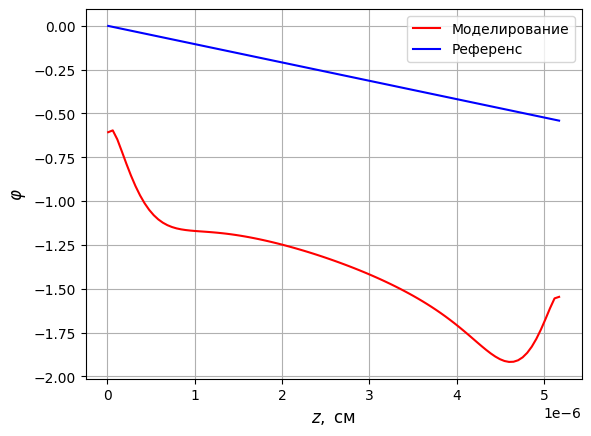

1.8610051397024256


In [35]:
def phase_calc(q_vec, z_all, N, omega, idx = 0):
    z = z_all.reshape((8,N))
    z_mean = np.mean(z, axis = 0)
    q_atoms = q_vec.reshape((8, N, 3))
    q1 = q_atoms[0,:,idx]
    phase = np.angle(q1)
    phase_unwrapped = np.unwrap(phase)
    k, b = np.polyfit(z_mean, phase_unwrapped, 1)
    k0 = omega / c
    n = -k/k0
    return phase_unwrapped, z_mean, phase, n

phase_np, z_mean, phases, n = phase_calc(q_ans, z_all, N, omega, idx = 0)
plt.plot(z_mean, phase_np, label = 'Моделирование', color = 'red')
ref_np = -omega / c * z_mean

plt.plot(z_mean, ref_np, label = 'Референс', color = 'blue')
plt.xlabel('$z, ~\\text{см}$', fontsize = 12)
plt.ylabel('$\\varphi$', fontsize = 12)
plt.grid()
plt.legend()
plt.show()
print(n)
